In [1]:
# !git clone https://github.com/kuiper2000/seasonal_tornado_forecast_demo.git
# !pip install descartes
# !pip install netCDF4
# !pip install cartopy
# import cartopy

Cloning into 'seasonal_tornado_forecast_demo'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 0), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 28.22 MiB | 22.92 MiB/s, done.


## Preparing User Defined DATA (can you for specific task)

In [1]:
import numpy as np
import sys
import importlib

# Add the directory containing Tornado_github.py to sys.path
# sys.path.insert(0, '/content/seasonal_tornado_forecast_demo/')

# Force reload to pick up any fixes in Tornado_github.py
if 'Tornado_github' in sys.modules:
    importlib.reload(sys.modules['Tornado_github']) # Reload by module name, not path
from Tornado_github import tornado_git

data_sst     = np.load('SST_EOFs_1995_2017_based.npz')
data_tornado = np.load('github_demo.npz')
# data_sst     = np.load('/content/seasonal_tornado_forecast_demo/SST_EOFs_1995_2017_based.npz')
# data_tornado = np.load('/content/seasonal_tornado_forecast_demo/github_demo.npz')

#20 SST PCs, 15 ensemble, 12 initialization months, 30 years (1992-2022), 12 month of forecast lead time
#20 SST EOFs, number lat, number of longitude  
print("=== SST keys ===")
for key in data_sst.files:
    print(f"  {key}: shape={data_sst[key].shape}, dtype={data_sst[key].dtype}")


print("\n=== Tornado keys ===")
for key in data_tornado.files:
    print(f"  {key}: shape={data_tornado[key].shape}, dtype={data_tornado[key].dtype}")
# CONUS tornado (number of reports) from 1992-2022, lat, lon (see next two variables)


pcs_obs_sst = data_sst['pcs_obs_sst'].mean(axis=1)
EOFs        = data_sst['EOF']
tornado     = data_tornado['tornado_month']

# Load all lat/lon arrays — we'll pick the right ones for the 1403 grid points
tornado_lat_full = data_tornado['lat']
tornado_lon_full = data_tornado['lon']

print(f"\ntornado shape     : {tornado.shape}")
print(f"lat/lon shape     : {tornado_lat_full.shape} / {tornado_lon_full.shape}")

tornado_model = tornado_git(tornado_data=tornado,
                            predictor=np.reshape(pcs_obs_sst, [20, 12, 30*12]),
                            init_year=1992)
print("tornado_git instance created successfully.")


=== SST keys ===
  pcs_obs_sst: shape=(20, 15, 12, 30, 12), dtype=float64
  EOF: shape=(20, 360, 576), dtype=float64
  variance: shape=(20,), dtype=float64

=== Tornado keys ===
  tornado_month: shape=(30, 1403), dtype=float64
  lat: shape=(23, 61), dtype=float64
  lon: shape=(23, 61), dtype=float64

tornado shape     : (30, 1403)
lat/lon shape     : (23, 61) / (23, 61)
tornado_git instance created successfully.


## Part 1 — Model Training

Train the forecast model using **leave-one-out cross-validation (LOOCV)** over the full historical record.
Running this cell once produces the regression coefficients, LOOCV skill scores, and SST mode importance needed for Part 2.
Set `INIT_MONTH`, `PRED_MONTH`, and `N_MODES` in the cell below, then run both cells in order.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
import importlib
import Tornado_github
importlib.reload(Tornado_github)
from Tornado_github import tornado_git
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import pearsonr


# ══════════════════════════════════════════════════════════════════════════════
#  PART 1 — train_tornado_model()
# ══════════════════════════════════════════════════════════════════════════════
def train_tornado_model(pcs_obs_sst,
                        tornado,
                        tornado_lat_full,
                        tornado_lon_full,
                        init_month=12,
                        pred_month=12,
                        n_modes=20,
                        init_year=1992):
    """
    Train the CONUS tornado forecast model via leave-one-out cross-validation
    and report average LOOCV skill over the full training period.

    Parameters
    ----------
    pcs_obs_sst      : ndarray  Ensemble-averaged SST PCs, reshapeable to
                                (n_modes, 12, n_years*12).
    tornado          : ndarray  Raw tornado count data.
    tornado_lat_full : ndarray  Latitude  grid — (n_lat, n_lon) or (n_grid,).
    tornado_lon_full : ndarray  Longitude grid — (n_lat, n_lon) or (n_grid,).
    init_month       : int (1–12)  Initialisation month          [default 12 = Dec].
    pred_month       : int (1–12)  SST predictor month           [default 12 = Dec].
    n_modes          : int         Number of SST modes            [default 20].
    init_year        : int         First year in dataset          [default 1992].

    Returns
    -------
    dict with keys
        'model'           : tornado_git instance (coef and percentile_min stored)
        'coef'            : ndarray (12, 12, n_years, n_modes, n_grid)
        'predict'         : ndarray LOOCV prediction array (full shape)
        'tor_arr'         : ndarray (n_years, n_grid)  reshaped tornado counts
        'obs_full'        : ndarray (n_years, n_grid)  ECDF percentile observations
        'loocv_r_years'   : ndarray (n_years,)  per-year spatial Pearson r
        'mean_loocv_r'    : float   mean LOOCV spatial r across all years
        'mode_importance' : ndarray (n_modes,)  mean |coef| per SST mode
        'init_month'      : int
        'pred_month'      : int
        'n_modes'         : int
        'init_year'       : int
    """
    months_label = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']

    # ── 1. Build predictor array (n_modes, 12, n_years*12) ───────────────────
    n_modes_sst = pcs_obs_sst.shape[0]
    predictor   = np.reshape(pcs_obs_sst, [n_modes_sst, 12, -1])
    n_years     = predictor.shape[2] // 12

    # ── 2. Create model & run LOOCV ───────────────────────────────────────────
    print("Building tornado_git model … ", end="", flush=True)
    model = tornado_git(tornado_data=tornado, predictor=predictor,
                        init_year=init_year)
    print("done.")
    print(f"Running leave-one-out cross-validation "
          f"(init={months_label[init_month-1]}, "
          f"pred={months_label[pred_month-1]}, modes={n_modes}) …")
    predict, coef = model._forecast()
    print("Cross-validation complete.\n")

    # ── 3. Retrieve reshaped tornado array & build ECDF percentiles ───────────
    tor_arr     = model.tornado            # (n_years, n_grid)  — reshaped by _forecast()
    n_grid      = tor_arr.shape[1]
    tor_pct_raw = np.zeros_like(tor_arr, dtype=float)
    for i in range(n_grid):
        ecdf = ECDF(tor_arr[:, i])
        tor_pct_raw[:, i] = ecdf(tor_arr[:, i])
    tor_pct_min  = tor_pct_raw.min(axis=0)
    model.tornado_percentile_min = tor_pct_min   # stored for predict_new()
    obs_full = tor_pct_raw                       # original ECDF scale

    # ── 4. LOOCV skill — per-year spatial Pearson r ───────────────────────────
    # predict shape: (n_modes, 12, 12, n_years, n_grid)
    # LOOCV preds are in min-removed space; add tor_pct_min back for fair comparison
    loocv_raw   = predict[n_modes - 1, init_month - 1, pred_month - 1, :, :]
    loocv_preds = np.clip(loocv_raw + tor_pct_min[np.newaxis, :], 0.0, 1.0)

    loocv_r_years = np.array([
        pearsonr(obs_full[y, :], loocv_preds[y, :])[0]
        for y in range(n_years)
    ])
    mean_loocv_r = float(np.nanmean(loocv_r_years))

    # ── 5. SST mode importance from LOOCV coefficients ────────────────────────
    # coef shape: (12, 12, n_years, n_modes, n_grid)
    coef_slice      = coef[init_month-1, pred_month-1, :, :n_modes, :]  # (n_years, n_modes, n_grid)
    mode_importance = np.abs(coef_slice).mean(axis=(0, 2))               # (n_modes,)

    # ── 6. Print summary ──────────────────────────────────────────────────────
    all_years = np.arange(init_year, init_year + n_years)
    best_idx  = int(np.argmax(loocv_r_years))
    worst_idx = int(np.argmin(loocv_r_years))
    print(f"{'═'*57}")
    print(f"  Training period          : {init_year}–{init_year + n_years - 1}")
    print(f"  Initialisation month     : {months_label[init_month-1]}")
    print(f"  SST predictor month      : {months_label[pred_month-1]}")
    print(f"  SST modes used           : {n_modes}")
    print(f"{'─'*57}")
    print(f"  Mean LOOCV spatial r     : {mean_loocv_r:>10.3f}")
    print(f"  Best  year  (r)  : {all_years[best_idx]}  "
          f"(r = {loocv_r_years[best_idx]:.3f})")
    print(f"  Worst year  (r)  : {all_years[worst_idx]}  "
          f"(r = {loocv_r_years[worst_idx]:.3f})")
    print(f"{'═'*57}\n")

    # ── 7. Training summary plots ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1 — LOOCV r per year
    ax1 = axes[0]
    bar_colors = ['crimson' if r < 0 else 'steelblue' for r in loocv_r_years]
    ax1.bar(all_years, loocv_r_years, color=bar_colors, edgecolor='k',
            linewidth=0.5, alpha=0.85)
    ax1.axhline(mean_loocv_r, color='k', lw=1.8, linestyle='--',
                label=f'Mean r = {mean_loocv_r:.3f}')
    ax1.axhline(0, color='grey', lw=0.8)
    ax1.set_xlabel('Year', fontsize=11)
    ax1.set_ylabel('Spatial Pearson r', fontsize=11)
    ax1.set_title(
        f'LOOCV Skill — Spatial r per Year\n'
        f'init = {months_label[init_month-1]},  '
        f'pred = {months_label[pred_month-1]},  modes = {n_modes}',
        fontsize=11
    )
    ax1.legend(fontsize=9)
    ax1.set_ylim(-1, 1)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.tick_params(axis='x', rotation=45, labelsize=8)

    # Panel 2 — SST mode importance
    ax2 = axes[1]
    bar_cols = plt.cm.YlOrRd(mode_importance / mode_importance.max())
    ax2.bar(range(1, n_modes + 1), mode_importance,
            color=bar_cols, edgecolor='k', linewidth=0.5)
    dom = int(np.argmax(mode_importance)) + 1
    ax2.bar(dom, mode_importance[dom - 1], color='crimson', edgecolor='k',
            linewidth=0.5, label=f'Dominant: Mode {dom}')
    ax2.set_xlabel('SST Mode', fontsize=11)
    ax2.set_ylabel('Mean |coefficient|', fontsize=11)
    ax2.set_title(
        f'SST Mode Importance\n'
        f'(mean |coef| averaged over all years & grid points)',
        fontsize=11
    )
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    plt.suptitle(
        f'CONUS Tornado Model — Training Summary  '
        f'({init_year}–{init_year + n_years - 1})',
        fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig('tornado_training_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved → tornado_training_summary.png")

    return {
        'model':           model,
        'coef':            coef,
        'predict':         predict,
        'tor_arr':         tor_arr,
        'obs_full':        obs_full,
        'loocv_r_years':   loocv_r_years,
        'mean_loocv_r':    mean_loocv_r,
        'mode_importance': mode_importance,
        'init_month':      init_month,
        'pred_month':      pred_month,
        'n_modes':         n_modes,
        'init_year':       init_year,
    }


print("train_tornado_model() is ready.")


train_tornado_model() is ready.


Building tornado_git model … done.
Running leave-one-out cross-validation (init=Dec, pred=Dec, modes=2) …
working on mode = 1
working on mode = 2
working on mode = 3
working on mode = 4
working on mode = 5
working on mode = 6
working on mode = 7
working on mode = 8
working on mode = 9
working on mode = 10
working on mode = 11
working on mode = 12
working on mode = 13
working on mode = 14
working on mode = 15
working on mode = 16
working on mode = 17
working on mode = 18
working on mode = 19
working on mode = 20
Cross-validation complete.

═════════════════════════════════════════════════════════
  Training period          : 1992–2021
  Initialisation month     : Dec
  SST predictor month      : Dec
  SST modes used           : 2
─────────────────────────────────────────────────────────
  Mean LOOCV spatial r     :      0.846
  Best  year  (r)  : 1992  (r = 0.924)
  Worst year  (r)  : 2011  (r = 0.695)
═════════════════════════════════════════════════════════



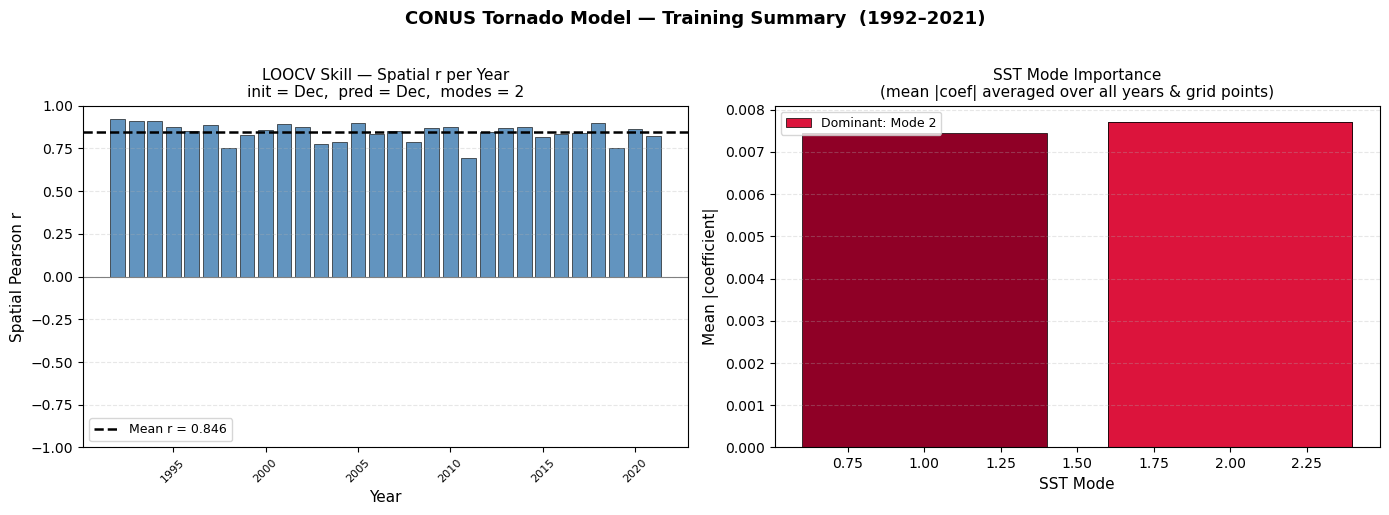

Figure saved → tornado_training_summary.png


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
#  PART 1 USER INPUTS — set parameters, then run this cell to train the model
# ══════════════════════════════════════════════════════════════════════════════

INIT_MONTH = 12   # Initialisation month (1–12)
PRED_MONTH = 12   # SST predictor month  (1–12)
N_MODES    = 2    # Number of SST modes to use in regression

training = train_tornado_model(
    pcs_obs_sst      = pcs_obs_sst,
    tornado          = tornado,
    tornado_lat_full = tornado_lat_full,
    tornado_lon_full = tornado_lon_full,
    init_month       = INIT_MONTH,
    pred_month       = PRED_MONTH,
    n_modes          = N_MODES,
)


## Part 2 — Prediction

Use the trained model to forecast CONUS tornado activity for a chosen year.

**Two ways to supply the SST predictor:**
- **Option A** — Pull SST PCs for any year already in the training dataset (enables in-sample verification against observed tornado data).
- **Option B** — Provide your own external SST PC vector of shape `(n_modes,)` for a true out-of-sample forecast.

Set `obs_tornado_year` to an integer within the training range to include observed vs forecast verification plots, or `None` for a pure forecast.

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
#  PART 2 — predict_conus_tornado()
# ══════════════════════════════════════════════════════════════════════════════

# ── Helper: proper ECDF inverse ───────────────────────────────────────────────
#
#  WHY this matters
#  ─────────────────
#  During training, tornado percentiles are computed with the statsmodels ECDF:
#      ECDF(v) = fraction of historical counts ≤ v   (a step function)
#  The regression is trained in "min-removed" space:
#      target = ECDF(count) - tor_pct_min            (so minimum = 0)
#  predict_new() adds tor_pct_min back before returning forecast_pct, so
#  forecast_pct[i] is already in the original ECDF scale [tor_pct_min[i], 1].
#
#  To convert forecast_pct back to a raw count we need the TRUE inverse of
#  the ECDF (quantile function).  np.percentile() uses linear interpolation
#  between sorted values, which is NOT the inverse of a step function —
#  it returns fractional values between integer tornado counts and
#  systematically underestimates totals for zero-heavy grid points.
#
#  _ecdf_invert() returns the SMALLEST observed integer count whose ECDF
#  value ≥ forecast_pct[i], exactly consistent with the forward transform.
#
def _ecdf_invert(counts, pct):
    """
    Step-function inverse of the statsmodels ECDF.

    Returns the smallest observed count v such that ECDF(v) >= pct,
    where ECDF(v) = mean(counts <= v).

    tor_pct_min is already embedded in pct (added back by predict_new()),
    so pct lives in [tor_pct_min, 1.0].  Any pct below tor_pct_min
    (e.g. after clipping) correctly maps to the minimum observed count.
    """
    uniq      = np.unique(counts)
    ecdf_vals = np.array([np.mean(counts <= v) for v in uniq])
    idx       = np.searchsorted(ecdf_vals, np.clip(pct, 0.0, 1.0), side='left')
    return float(uniq[min(idx, len(uniq) - 1)])


def predict_conus_tornado(sst_pcs_user,
                          training_result,
                          tornado_lat_full,
                          tornado_lon_full,
                          obs_tornado_year=None):
    """
    Forecast CONUS tornado activity using a user-supplied SST PC vector.

    Parameters
    ----------
    sst_pcs_user     : array-like (n_modes,)
                       SST PC vector for the target period.
                       Option A — from a training-year (in-sample verification).
                       Option B — any external vector (out-of-sample forecast).
    training_result  : dict   Output of train_tornado_model().
    tornado_lat_full : ndarray  Latitude  grid — (n_lat, n_lon) or (n_grid,).
    tornado_lon_full : ndarray  Longitude grid — (n_lat, n_lon) or (n_grid,).
    obs_tornado_year : int or None
                       Year within the training range for verification, or
                       None for a pure forecast with no observed comparison.

    Returns
    -------
    dict with keys
        'forecast_pct'         : ndarray  Per-grid forecast (original ECDF scale).
        'conus_total_forecast' : float    Predicted total CONUS tornado count.
        'conus_total_observed' : float or None
        'correlation'          : float or None  Spatial Pearson r.
    """
    model        = training_result['model']
    coef         = training_result['coef']
    tor_arr      = training_result['tor_arr']
    obs_full     = training_result['obs_full']
    init_month   = training_result['init_month']
    pred_month   = training_result['pred_month']
    n_modes      = training_result['n_modes']
    init_year    = training_result['init_year']
    n_years      = tor_arr.shape[0]
    n_grid       = tor_arr.shape[1]
    months_label = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']

    sst_pcs_user = np.asarray(sst_pcs_user).ravel()

    # ── 1. Make forecast via pre-trained coefficients ─────────────────────────
    #   predict_new() internally does:
    #       raw_pred  = sst_pcs @ coef_used         ← min-removed percentile space
    #       forecast  = raw_pred + tor_pct_min       ← restore original ECDF scale
    #       forecast  = clip(forecast, 0, 1)
    #   So forecast_pct[i] is directly comparable to obs_full[year, i].
    forecast_pct, coef_used = model.predict_new(
        sst_pcs    = sst_pcs_user,
        init_month = init_month,
        pred_month = pred_month,
        coef       = coef,
        n_modes    = n_modes,
    )

    # ── 2. Back-transform: ECDF percentile → raw tornado count ───────────────
    #   Uses _ecdf_invert() (step-function inverse) instead of np.percentile()
    #   (linear interpolation) to stay consistent with the forward ECDF transform.
    forecast_count       = np.array([
        _ecdf_invert(tor_arr[:, i], forecast_pct[i])
        for i in range(n_grid)
    ])
    conus_total_forecast = forecast_count.sum()

    # ── 3. Climatological reference per grid point ────────────────────────────
    #   WHY NOT 0.5?
    #   Each grid point has a different ECDF distribution. Sparse tornado regions
    #   (e.g. 110°W, 40°N) may have 70-90 % zero-tornado years, giving
    #   tor_pct_min ≈ 0.7-0.9. Even with zero regression signal, forecast_pct
    #   sits near tor_pct_min >> 0.5, so (forecast_pct - 0.5) is always positive
    #   → spurious "always above-normal" signal.
    #   Active tornado regions (e.g. 100°W, 35°N) have tor_pct_min ≈ 0.03, so
    #   (forecast_pct - 0.5) is often negative → spurious "always below-normal".
    #
    #   Fix: subtract each grid point's own climatological mean ECDF percentile.
    #   This centres the anomaly at 0 for climatological conditions everywhere.
    clim_ref = obs_full.mean(axis=0)    # (n_grid,)  mean ECDF pct per grid point

    # ── 4. Observed data for verification (optional) ──────────────────────────
    has_obs              = False
    obs_yr               = None
    r_val                = None
    conus_total_observed = None

    if obs_tornado_year is not None:
        yr_min, yr_max = init_year, init_year + n_years - 1
        if yr_min <= obs_tornado_year <= yr_max:
            year_idx             = obs_tornado_year - init_year
            obs_yr               = obs_full[year_idx, :]
            r_val, _             = pearsonr(obs_yr, forecast_pct)
            conus_total_observed = tor_arr[year_idx, :].sum()
            has_obs              = True
        else:
            print(f"⚠  obs_tornado_year {obs_tornado_year} is outside the training "
                  f"range [{yr_min}, {yr_max}] — proceeding without verification.")

    # ── 5. Print summary ──────────────────────────────────────────────────────
    print(f"{'═'*57}")
    print(f"  Initialisation month     : {months_label[init_month-1]}")
    print(f"  SST predictor month      : {months_label[pred_month-1]}")
    print(f"  SST modes used           : {n_modes}")
    print(f"{'─'*57}")
    print(f"  CONUS tornado forecast   : {conus_total_forecast:>10,.0f}")
    if has_obs:
        print(f"  CONUS tornado observed   : {conus_total_observed:>10,.0f}")
        print(f"  Spatial correlation (r)  : {r_val:>10.3f}")
    print(f"{'═'*57}\n")

    # ── 6. Activity mask & anomalies (relative to grid-point climatology) ─────
    tor_lat    = tornado_lat_full.ravel()
    tor_lon    = tornado_lon_full.ravel()
    tor_mean   = tor_arr.mean(axis=0)
    act_thresh = np.percentile(tor_mean[tor_mean > 0], 25)
    active     = tor_mean >= act_thresh

    # Anomaly = departure from each grid point's own climatological mean pct
    fore_anom = forecast_pct[active] - clim_ref[active]
    obs_anom  = (obs_yr[active] - clim_ref[active]) if has_obs else None

    # Dynamic symmetric colour range based on actual anomaly spread
    all_anoms = np.concatenate([fore_anom, obs_anom]) if has_obs else fore_anom
    absmax    = max(float(np.abs(all_anoms).max()), 0.05)

    # ── 7. Shared plot helpers ────────────────────────────────────────────────
    cmap   = plt.cm.RdBu_r
    norm   = mcolors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)
    proj   = ccrs.PlateCarree()
    extent = [-125, -65, 22, 52]

    all_years      = np.arange(init_year, init_year + n_years)
    obs_counts_all = tor_arr.sum(axis=1)
    clim_mean      = obs_counts_all.mean()

    mode_imp = np.abs(coef_used).mean(axis=1)
    dom      = int(np.argmax(mode_imp)) + 1

    def _draw_map(ax, anom, title):
        ax.set_extent(extent, crs=proj)
        ax.add_feature(cfeature.LAND,      facecolor='lightgrey', zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor='aliceblue', zorder=0)
        ax.add_feature(cfeature.LAKES,     facecolor='aliceblue', zorder=0)
        ax.add_feature(cfeature.STATES,    linewidth=0.5, edgecolor='white',   zorder=1)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.7, edgecolor='grey',    zorder=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='dimgrey', zorder=2)
        ax.scatter(tor_lon[active], tor_lat[active], c=anom,
                   cmap=cmap, norm=norm, s=28, marker='s',
                   transform=proj, zorder=3, linewidths=0)
        gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                          color='grey', alpha=0.4, linestyle='--')
        gl.top_labels = False; gl.right_labels = False
        gl.xlabel_style = {'size': 8}; gl.ylabel_style = {'size': 8}
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    def _draw_bar(ax):
        ax.bar(all_years, obs_counts_all, color='steelblue', alpha=0.45,
               label='Observed (all years)', zorder=2)
        if has_obs:
            ax.bar(obs_tornado_year, conus_total_observed, color='navy', alpha=0.9,
                   label=f'Observed {obs_tornado_year}', zorder=3)
        ax.axhline(conus_total_forecast, color='crimson', lw=2.0, linestyle='-',
                   label=f'Forecast = {conus_total_forecast:,.0f}', zorder=4)
        ax.axhline(clim_mean, color='k', lw=1.3, linestyle='--',
                   label=f'Clim. mean = {clim_mean:,.0f}')
        ax.set_xlabel('Year', fontsize=10)
        ax.set_ylabel('CONUS tornado count', fontsize=10)
        bar_title = (f'CONUS Total Count\nFcst = {conus_total_forecast:,.0f}'
                     + (f'  |  Obs = {conus_total_observed:,.0f}' if has_obs else ''))
        ax.set_title(bar_title, fontsize=10)
        ax.legend(fontsize=7, ncol=1)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xlim(init_year - 1, init_year + n_years)
        ax.tick_params(axis='x', rotation=45, labelsize=8)

    def _draw_modes(ax):
        bar_cols = plt.cm.YlOrRd(mode_imp / mode_imp.max())
        ax.bar(range(1, len(mode_imp)+1), mode_imp,
               color=bar_cols, edgecolor='k', linewidth=0.5)
        ax.bar(dom, mode_imp[dom-1], color='crimson', edgecolor='k',
               linewidth=0.5, label=f'Dominant: M{dom}')
        ax.set_xlabel('SST Mode', fontsize=10)
        ax.set_ylabel('Mean |coefficient|', fontsize=10)
        ax.set_title('SST mode importance\n(this forecast)', fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.legend(fontsize=8)

    suptitle = (
        f'CONUS Tornado Forecast  '
        f'(init = {months_label[init_month-1]},  pred = {months_label[pred_month-1]})\n'
        f'CONUS total ▸ Forecast = {conus_total_forecast:,.0f}'
        + (f'  |  Observed = {conus_total_observed:,.0f}  |  Spatial r = {r_val:.3f}'
           if has_obs else '')
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # ── Layout A: with observed verification (2 × 3) ──────────────────────
        if has_obs:
            fig = plt.figure(figsize=(18, 11))

            ax1 = fig.add_subplot(2, 3, 1)
            ax1.scatter(obs_yr, forecast_pct, s=4, alpha=0.35, color='steelblue')
            lims = [min(obs_yr.min(), forecast_pct.min()),
                    max(obs_yr.max(), forecast_pct.max())]
            ax1.plot(lims, lims, 'r--', lw=1.5, label='1:1 line')
            ax1.set_xlabel('Observed percentile', fontsize=10)
            ax1.set_ylabel('Forecast percentile', fontsize=10)
            ax1.set_title(f'Forecast vs Observed  (r = {r_val:.3f})', fontsize=10)
            ax1.legend(fontsize=8); ax1.grid(alpha=0.3, linestyle='--')

            sort_idx = np.argsort(obs_yr)
            ax2 = fig.add_subplot(2, 3, 2)
            ax2.plot(obs_yr[sort_idx],       'k-',  lw=1.2, label='Observed', alpha=0.85)
            ax2.plot(forecast_pct[sort_idx], 'r--', lw=1.2, label='Forecast', alpha=0.85)
            ax2.set_xlabel('Grid point (sorted by observed)', fontsize=10)
            ax2.set_ylabel('Tornado percentile', fontsize=10)
            ax2.set_title('Grid-point comparison', fontsize=10)
            ax2.legend(fontsize=8); ax2.grid(alpha=0.3, linestyle='--')

            _draw_modes(fig.add_subplot(2, 3, 3))

            _draw_map(fig.add_subplot(2, 3, 4, projection=proj),
                      fore_anom, 'Forecast anomaly')
            _draw_map(fig.add_subplot(2, 3, 5, projection=proj),
                      obs_anom,  f'Observed anomaly  ({obs_tornado_year})')
            _draw_bar(fig.add_subplot(2, 3, 6))

            cbar_ax = fig.add_axes([0.635, 0.07, 0.013, 0.36])

        # ── Layout B: forecast only (1 × 3) ───────────────────────────────────
        else:
            fig = plt.figure(figsize=(18, 5.5))
            _draw_modes(fig.add_subplot(1, 3, 1))
            _draw_map(fig.add_subplot(1, 3, 2, projection=proj),
                      fore_anom, 'Forecast anomaly')
            _draw_bar(fig.add_subplot(1, 3, 3))
            cbar_ax = fig.add_axes([0.655, 0.10, 0.013, 0.78])

        cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
        cb.set_label(
            f'Tornado percentile anomaly\n(relative to grid-point climatology)\n'
            f'range: ±{absmax:.2f}',
            fontsize=9
        )
        cb.set_ticks([-absmax, -absmax/2, 0, absmax/2, absmax])
        cb.ax.tick_params(labelsize=8)
        cb.ax.axhline(0, color='k', linewidth=0.8, linestyle='--')

    plt.suptitle(suptitle, fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    out_fname = 'tornado_prediction.png'
    plt.savefig(out_fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved → {out_fname}")

    return {
        'forecast_pct':         forecast_pct,
        'conus_total_forecast': conus_total_forecast,
        'conus_total_observed': conus_total_observed,
        'correlation':          r_val,
        'clim_ref':             clim_ref,
    }


print("predict_conus_tornado() is ready.")


predict_conus_tornado() is ready.


═════════════════════════════════════════════════════════
  Initialisation month     : Dec
  SST predictor month      : Dec
  SST modes used           : 2
─────────────────────────────────────────────────────────
  CONUS tornado forecast   :        456
  CONUS tornado observed   :        758
  Spatial correlation (r)  :      0.800
═════════════════════════════════════════════════════════



/var/folders/x1/nb2x5h5j08b2xx8xkc64r43m0000gn/T/ipykernel_45377/3103493070.py:294: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/Shared/miniconda3/envs/claude_code/lib/py

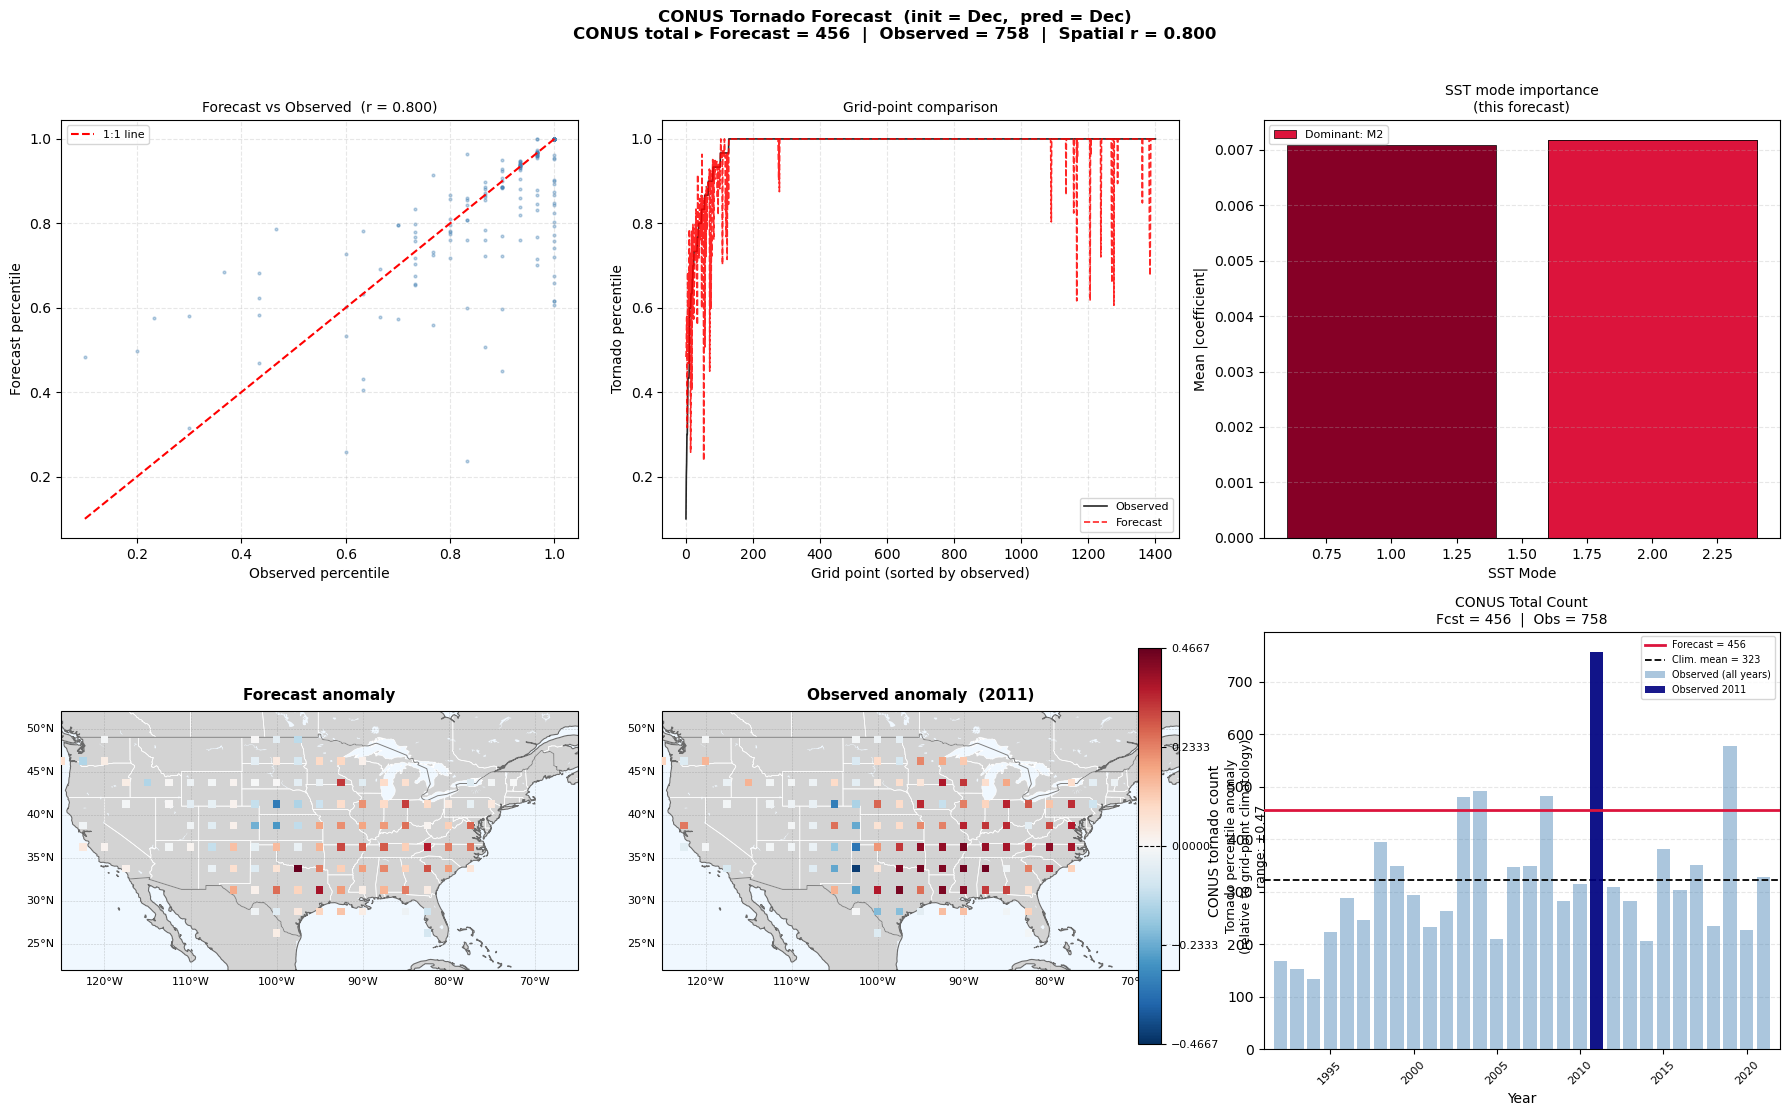

Figure saved → tornado_prediction.png

CONUS tornado forecast   :        456
CONUS tornado observed   :        758
Spatial correlation (r)  :      0.800


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
#  PART 2 USER INPUTS — supply a predictor, then run this cell
# ══════════════════════════════════════════════════════════════════════════════

# ── Option A: pull SST PCs from a training-period year (in-sample) ───────────
#    This lets you verify the forecast against known observed tornado data.
target_year    = 2011   # ← any year in [1992, 2021]

year_idx       = target_year - training['init_year']
dates_1M       = pd.date_range(
    f"{training['init_year']}-{training['init_month']:02d}",
    periods=training['tor_arr'].shape[0] * 12, freq='1ME'
)
predictor_posi = np.where(dates_1M.month == training['pred_month'])[0]
sst_pcs_user   = training['model'].predictor[
                     :, training['init_month'] - 1,
                     predictor_posi[year_idx]
                 ]   # shape: (n_modes,)

# ── Option B: supply your own external SST PC vector ─────────────────────────
#    Uncomment and fill in the array below to use an out-of-sample predictor.
# sst_pcs_user = np.array([...])   # shape must be (n_modes,) = (N_MODES,)

# ── Verification: set to an int in [1992, 2021] to compare with observations,
#                  or None for a pure out-of-sample forecast (no obs comparison)
OBS_YEAR = target_year   # ← set to None if using Option B or no obs available

# ── Run prediction ────────────────────────────────────────────────────────────
result = predict_conus_tornado(
    sst_pcs_user     = sst_pcs_user,
    training_result  = training,
    tornado_lat_full = tornado_lat_full,
    tornado_lon_full = tornado_lon_full,
    obs_tornado_year = OBS_YEAR,
)

print(f"\nCONUS tornado forecast   : {result['conus_total_forecast']:>10,.0f}")
if result['conus_total_observed'] is not None:
    print(f"CONUS tornado observed   : {result['conus_total_observed']:>10,.0f}")
    print(f"Spatial correlation (r)  : {result['correlation']:>10.3f}")
